# 06 - Comparaison finale : baseline vs improved v10 (dataset RSNA)

Ce notebook compare `baseline_prompt_0` et `improved_prompt_10` (comparaison de symétrie gauche/droite, le meilleur prompt trouvé pour RSNA) sur exactement les mêmes 100 cas RSNA, jamais vus par le classificateur pixel auxiliaire pendant son entraînement (`data/rsna_holdout_sample_100.txt`).

C'est la comparaison officielle pour la section "Amélioration mesurée" du rapport (20% de la note). Voir `notebooks/02_research_phase.ipynb` pour le glossaire complet des métriques et l'historique de la phase de recherche (Kaggle + tous les prompts RSNA testés : v4 à v11, tentative de vote de prompts).

**Pré-requis** : avoir lancé les deux commandes suivantes (mêmes 100 cas pour les deux) :
```
python scripts/run_prompt_evaluation.py --mode baseline --prompt-version 0 --case-ids-file data/rsna_holdout_sample_100.txt --cases-path data/cases.csv --db-path data/database.sqlite
python scripts/run_prompt_evaluation.py --mode improved --prompt-version 10 --case-ids-file data/rsna_holdout_sample_100.txt --cases-path data/cases.csv --db-path data/database.sqlite
```

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.database import get_evaluations
from src.metrics import sensitivity, specificity, macro_f1, confusion_matrix_numpy

DB_PATH = Path('..') / 'data' / 'database.sqlite'
CLASSES = ['normal', 'suspected_opacity', 'uncertain']

df = pd.DataFrame(get_evaluations(DB_PATH))
df = df[((df['prompt_name'] == 'baseline') & (df['prompt_version'] == 'v0')) |
        ((df['prompt_name'] == 'improved') & (df['prompt_version'] == 'v10'))]
df['label'] = df['prompt_name'] + ' ' + df['prompt_version']
df['label'].value_counts()

label
improved v10    120
baseline v0     100
Name: count, dtype: int64

## Phase de test sur touts les prompts

Test des prompt utilisé précédemment (v0 à v5) mais less résultats sont mauvais (~35-40%). Plusieurs approches sont testés : 
- tentatives d'amélioration du `imporved_prompt_v4'
- tentatives d'usage de modèle auxiliaire 
- tentative de combinason de prompts avec des biais sans intersection basé sur une étude de 2026 (https://www.medrxiv.org/content/10.64898/2026.04.10.26347909v1.full) -> le prompt v10 a émergé pendant cette phase de test (~70%)

In [2]:
# Historique complet des prompts "improved" testés sur RSNA
# NB : échantillons de tailles/cas différents (cf. colonne n)
# pas une comparaison tête-à-tête. Seuls baseline v0 et v10 le sont (sections suivantes).
PROMPT_IDEAS = {
    'v4':'Prompt simple (Kaggle)',
    'v5':'Raisonnement réordonné + checklist',
    'v6':'Checklist artefacts', # checklist pour identifier les objets externes (ex. tube, cathéter, pacemaker, etc.)
    'v7':'+ exclure matériel externe',
    'v8':'+ ne regarder que les poumons',
    'v9':'Seuil conservateur',
    'v10':'Symétrie gauche/droite',
    'v11':'Prompt minimal',
}

df_all = pd.DataFrame(get_evaluations(DB_PATH))
research = df_all[df_all['prompt_name'] == 'improved'].copy()  # exclut baseline et improved_aux


def prompt_metrics(sub_df, gt_col='ground_truth_label', pred_col='predicted_class'):
    valid = sub_df.dropna(subset=[gt_col, pred_col])
    return {
        'n': len(valid),
        'accuracy': (valid[gt_col] == valid[pred_col]).mean(),
        'sensitivity': sensitivity(valid[gt_col], valid[pred_col]),
        'specificity': specificity(valid[gt_col], valid[pred_col]),
        'macro_f1': macro_f1(valid[gt_col], valid[pred_col]),
        'uncertain_rate': (valid[pred_col] == 'uncertain').mean(),
    }

versions = sorted(research['prompt_version'].unique(), key=lambda v: int(v[1:]))
rows = []
for version in versions:
    m = prompt_metrics(research[research['prompt_version'] == version])
    m['idée'] = PROMPT_IDEAS.get(version, '')
    m['version'] = version
    rows.append(m)

research_df = (pd.DataFrame(rows)
              .set_index('version')[['idée', 'n', 'accuracy', 'sensitivity', 'specificity', 'macro_f1', 'uncertain_rate']])
research_df

,idée,n,accuracy,sensitivity,specificity,macro_f1,uncertain_rate
version,,,,,,,
v4,Prompt simple (Kaggle),100,0.400000,0.640000,0.160000,0.434659,0.340000
v5,Raisonnement réordonné + checklist,20,0.400000,0.700000,0.100000,0.395257,0.300000
v6,Checklist artefacts,20,0.350000,0.400000,0.300000,0.466063,0.500000
v7,+ exclure matériel externe,20,0.350000,0.700000,0.000000,0.333333,0.450000
v8,+ ne regarder que les poumons,20,0.350000,0.700000,0.000000,0.318182,0.400000
v9,Seuil conservateur,10,0.300000,0.000000,0.750000,0.333333,0.500000
v10,Symétrie gauche/droite,120,0.716667,0.516667,0.916667,0.707532,0.008333
v11,Prompt minimal,10,0.600000,1.000000,0.000000,0.375000,0.000000


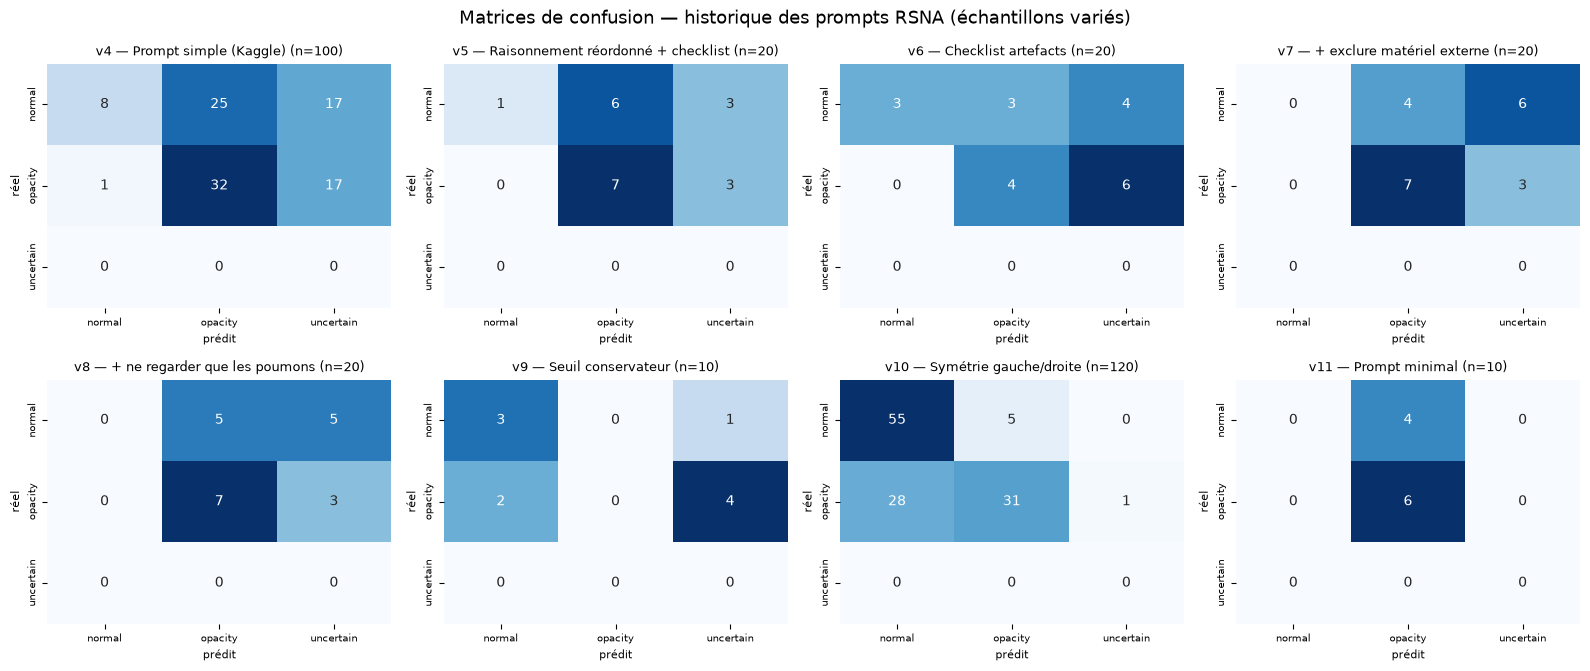

In [3]:
# Matrice de confusion de chaque prompt (rappel : tailles d'échantillon différentes, cf. titres n=...)
SHORT = ['normal', 'opacity', 'uncertain']  # libellés courts pour lisibilité
ncols = 4
nrows = (len(versions) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.4 * nrows))
axes = axes.ravel()

for ax, version in zip(axes, versions):
    sub = research[research['prompt_version'] == version]
    cm = confusion_matrix_numpy(sub['ground_truth_label'], sub['predicted_class'], CLASSES)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=SHORT, yticklabels=SHORT, ax=ax)
    ax.set_title(f"{version} — {PROMPT_IDEAS.get(version, '')} (n={len(sub)})", fontsize=9)
    ax.set_xlabel('prédit', fontsize=8)
    ax.set_ylabel('réel', fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes[len(versions):]:  # masque les cases vides de la grille
    ax.axis('off')

fig.suptitle('Matrices de confusion — historique des prompts RSNA (échantillons variés)', fontsize=13)
plt.tight_layout()
plt.show()

Pour la suite on garde donc le meilleur prompt (**prompt v10**) pour le comparer avec les résultats de la baseline sur les mêmes images du dataset RSNA.

## Comparaison des résulats : `baseline` vs `prompt v10`

### Tableau récapitulatif des métriques

(voir `02_research_phase.ipynb` pour la définition de chaque métrique)

In [2]:
def compute_metrics_df(sub_df, gt_col='ground_truth_label', pred_col='predicted_class'):
    valid = sub_df.dropna(subset=[gt_col, pred_col])
    n = len(valid)
    accuracy = (valid[gt_col] == valid[pred_col]).mean()
    uncertain_rate = (valid[pred_col] == 'uncertain').mean()
    return {
        'n': n,
        'accuracy': accuracy,
        'macro_f1': macro_f1(valid[gt_col], valid[pred_col]),
        'sensitivity': sensitivity(valid[gt_col], valid[pred_col]),
        'specificity': specificity(valid[gt_col], valid[pred_col]),
        'uncertain_rate': uncertain_rate,
    }

summary_rows = []
for label in df['label'].unique():
    sub = df[df['label'] == label]
    m = compute_metrics_df(sub)
    m['label'] = label
    summary_rows.append(m)

summary_df = pd.DataFrame(summary_rows).set_index('label')
summary_df

,n,accuracy,macro_f1,sensitivity,specificity,uncertain_rate
label,,,,,,
baseline v0,100,0.290000,0.405844,0.460000,0.120000,0.670000
improved v10,120,0.716667,0.707532,0.516667,0.916667,0.008333


### Matrices de confusion

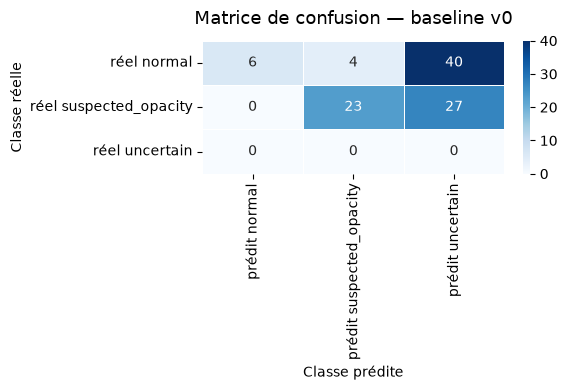

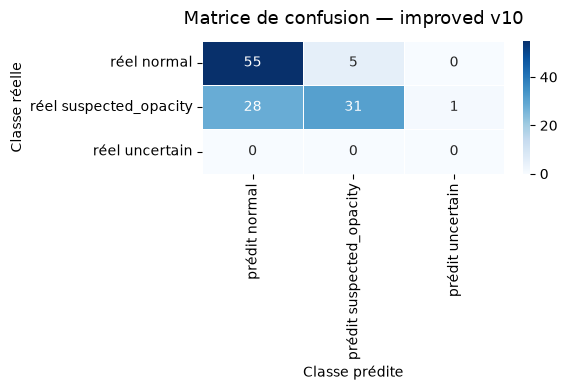

In [3]:
for label in df['label'].unique():
    sub = df[df['label'] == label]
    cm = confusion_matrix_numpy(sub['ground_truth_label'], sub['predicted_class'], CLASSES)
    cm_df = pd.DataFrame(cm, index=[f'réel {c}' for c in CLASSES], columns=[f'prédit {c}' for c in CLASSES])

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title(f'Matrice de confusion — {label}', fontsize=13, pad=12)
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')
    plt.tight_layout()
    plt.show()

### Amélioration mesurée : baseline vs improved v10

In [4]:
baseline_row = summary_df.loc['baseline v0']
best_row = summary_df.loc['improved v10']

print('Baseline (v0) vs improved v10 (comparaison de symétrie)\n')
for metric in ['accuracy', 'macro_f1', 'sensitivity', 'specificity', 'uncertain_rate']:
    gain = best_row[metric] - baseline_row[metric]
    print(f"{metric:12s} : baseline {baseline_row[metric]:.1%}  ->  v10 {best_row[metric]:.1%}  (gain {gain:+.1%})")

Baseline (v0) vs improved v10 (comparaison de symétrie)

accuracy     : baseline 29.0%  ->  v10 71.7%  (gain +42.7%)
macro_f1     : baseline 40.6%  ->  v10 70.8%  (gain +30.2%)
sensitivity  : baseline 46.0%  ->  v10 51.7%  (gain +5.7%)
specificity  : baseline 12.0%  ->  v10 91.7%  (gain +79.7%)
uncertain_rate : baseline 67.0%  ->  v10 0.8%  (gain -66.2%)


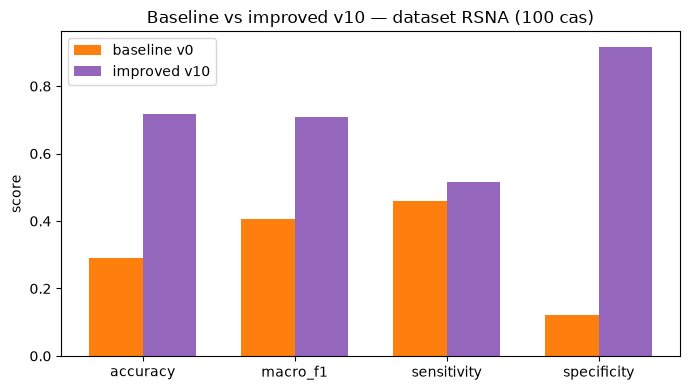

In [5]:
metrics_to_plot = ['accuracy', 'macro_f1', 'sensitivity', 'specificity']
x = range(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - width / 2 for i in x], [baseline_row[m] for m in metrics_to_plot], width, label='baseline v0', color='tab:orange')
ax.bar([i + width / 2 for i in x], [best_row[m] for m in metrics_to_plot], width, label='improved v10', color='tab:purple')

ax.set_xticks(list(x))
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('score')
ax.set_title('Baseline vs improved v10 — dataset RSNA (100 cas)')
ax.legend()
plt.tight_layout()
plt.show()

### Obeservations et conclusion 


**Les améliorations avec le prompt v10 par rapport à la baseline :**

- Le gain sur `accuracy` est de **42,7%** et de **79,7%** pour la `specificity`
- La `sensitivity` est aussi améliorée, mais seulment de **5.7%**: on passe de **46.0%** à **51.7**. Donc la v10 attrape 26/50 opacités contre 23/50 pour la baseline (détection quasi équivalente). Toutefois, le prompte v10 permet de classifier correctement 46/50 normaux contre 6/50. Il y a donc moins de fausses alertes/abstentions

**Limite** : Il y a un nombre importnat de faux négatif : 28/60 soit ~46% de `suepected_opacity` classifié en `normal`

**Conclusion :** v10 transforme un modèle qui s'abstient (67 % d'uncertain, spécificité 12 %) en un modèle qui décide et distingue les cas (spécificité 92 %), au prix d'une sensibilité qui reste modérée (52 %). Cela reste acceptable pour un prototype pédagogique sous avertissement qui interdit tout usage de dépistage réel.

